## **_Sample Modeling_** (for Reinforcement Learning)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다.
* PPO는 기본적으로 Linear 모델을 지원합니다.

In [79]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------

csv_file_name = "./drying_oven_sensor_v1.1.csv"
model_path_name = "./ppo_dryer_control_v1.1.pth"
global_num_samples = 10000

In [85]:
import pandas as pd
import numpy as np

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25

# 시간축 (초 단위 가정)
time = np.arange(num_samples)

# 2. 내부 온도(inner_temp) 생성 로직
inner_temp = np.full(num_samples, target_temp, dtype=float)

# 초기 가열 구간 (0~10%)
heating_end = int(num_samples * 0.1)
inner_temp[:heating_end] = np.linspace(initial_temp, target_temp, heating_end)

# 급격한 온도 하강 시나리오 (40% 지점, 예: 문 열림)
drop_start = int(num_samples * 0.4)
duration = 100 # 변화 지속 시간
inner_temp[drop_start:drop_start+duration] -= np.linspace(0, 30, duration)
# 복구 구간
inner_temp[drop_start+duration:drop_start+duration*2] = np.linspace(inner_temp[drop_start+duration-1], target_temp, duration)

spike_ratios = [0.7, 0.8]
for ratio in spike_ratios:
    # 급격한 온도 상승 시나리오 (70% 지점, 예: 히터 과열)
    spike_start = int(num_samples * ratio)
    inner_temp[spike_start:spike_start+duration] += np.linspace(0, 60, duration)
    # 복구 구간
    inner_temp[spike_start+duration:spike_start+duration*2] = np.linspace(inner_temp[spike_start+duration-1], target_temp, duration)


# 미세 노이즈 추가 (실제 데이터 느낌 부여)
inner_temp += np.random.normal(0, 0.4, num_samples)

# 3. 기타 센서 데이터 생성
humidity = np.linspace(80, 15, num_samples) + np.random.normal(0, 1, num_samples) # 습도 점진적 감소
weight = np.linspace(5.0, 4.2, num_samples) + np.random.normal(0, 0.01, num_samples) # 무게 감소
outer_temp = np.random.normal(22, 1, num_samples) # 외부 온도 (평균 22도)
pressure = np.random.normal(1013, 2, num_samples) # 대기압

# 4. 사용자 조치 및 팬 RPM 결정 (Down:0, Keep: 1, Up:2)
def determine_action(temp):
    if temp < 78: return "0"   # 온도가 낮으면 팬 속도 감소(열 보존)
    elif temp > 82: return "2" # 온도가 높으면 팬 속도 증가(열 배출)
    else: return "1"           # 적정 온도 유지

actions = [determine_action(t) for t in inner_temp]

# Action에 따른 팬 RPM 수치 할당
fan_rpm = []
for action in actions:
    if action == "0": fan_rpm.append(1200 + np.random.randint(-50, 50))
    elif action == "2": fan_rpm.append(1800 + np.random.randint(-50, 50))
    else: fan_rpm.append(1500 + np.random.randint(-30, 30))

# 5. 데이터프레임 생성 및 확인
df = pd.DataFrame({
    'timestamp': time,
    'inner_temp': np.round(inner_temp, 2),
    'humidity': np.round(humidity, 2),
    'weight': np.round(weight, 3),
    'outer_temp': np.round(outer_temp, 2),
    'pressure': np.round(pressure, 2),
    'fan_rpm': fan_rpm,
    'user_action': actions
})

# 결과 출력 (상위 10개 및 하강 구간 확인)
print("--- 초기 가열 구간 데이터 ---")
print(df.head(10))
print("\n--- 온도 하강 발생 구간 데이터 (4000번 인덱스 부근) ---")
print(df.iloc[drop_start:drop_start + duration])
for ratio in spike_ratios:
    # 급격한 온도 상승 시나리오 (70% 지점, 예: 히터 과열)
    spike_start = int(num_samples * ratio)
    print(f"\n--- 급격한 온도 상승 구간 데이터 (ration = {ratio}) ---")
    print(df.iloc[spike_start:spike_start + duration])
# CSV 파일로 저장
df.to_csv(csv_file_name, index=False)


--- 초기 가열 구간 데이터 ---
   timestamp  inner_temp  humidity  weight  outer_temp  pressure  fan_rpm  \
0          0       24.71     77.34   4.995       22.89   1011.89     1214   
1          1       25.03     79.63   4.999       22.20   1012.31     1249   
2          2       25.27     78.79   5.005       22.41   1012.03     1192   
3          3       24.64     79.60   4.993       24.35   1013.82     1239   
4          4       24.77     77.77   5.000       21.34   1010.14     1194   
5          5       25.00     78.46   5.006       21.21   1013.80     1175   
6          6       24.85     82.15   5.000       23.52   1012.68     1222   
7          7       25.52     78.62   5.003       22.02   1009.96     1213   
8          8       25.31     79.97   5.012       22.70   1012.34     1174   
9          9       25.16     79.88   4.996       23.80   1014.70     1207   

  user_action  
0           0  
1           0  
2           0  
3           0  
4           0  
5           0  
6           0  
7  

#### Step 2 Env 생성

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class DryerEnv(gym.Env):
    """
    RecurrentPPO 학습을 위한 건조기 온도 제어 환경
    목표: 팬 RPM을 조절하여 내부 온도를 80도로 유지하기
    """
    init_sim_data = [{
            "inner_temp": 79.5,  # 실측 온도
            "error": -0.5,       # 실측 온도 - 목표 온도
            "humidity": 45.2,    # 실측 습도
            "weight": 4.65,      # 실측 무게
            "outer_temp": 22.1,
            "pressure": 1012.8,
            "fan_rpm": 1550.0,
            "user_action": 0
        },
        {
            "inner_temp": 25,  # 실측 온도
            "error": -55,      # 실측 온도 - 목표 온도
            "humidity": 80,    # 실측 습도
            "weight": 5.0,     # 실측 무게
            "outer_temp": 22.0,
            "pressure": 1013.0,
            "fan_rpm": 1500.0,
            "user_action": 2
        }
    ]

    def __init__(self, is_simulatation=True):
        super(DryerEnv, self).__init__()

        # 1. Action Space: [0: DOWN, 1: KEEP, 2: UP]
        self.action_space = spaces.Discrete(3)

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32
        )        
        self.is_simulation = is_simulatation

        self.target_temp = 80.0
        self.max_steps = 10000
        self.state = np.array([])
        self.terminated = False
        self.reset()
    
    def _generate_simul_data(self, state, action):
        inner_temp, error, humidity, weight, outer_temp, pressure, fan_rpm = state
        # 습도 및 무게 자연 감소
        humidity = max(15.0, humidity - 0.01)
        weight = max(4.2, weight - 0.0001)

        # 1. 액션에 따른 팬 RPM 변화
        if action == 0:   # DOWN: 팬 속도 감소 -> 냉각 효율 저하 -> 온도 상승 유도
            fan_rpm -= 100
        elif action == 2: # UP: 팬 속도 증가 -> 냉각 효율 상승 -> 온도 하락 유도
            fan_rpm += 100
        
        fan_rpm = np.clip(fan_rpm, 0, 3000) # 가동 범위
    
        # 2. 열 평형 방정식 (핵심 로직)
        # 히터는 일정한 열을 공급 (Heater Input)
        heater_input = 10.0 
    
        # [핵심] 팬 RPM에 비례하는 냉각 계수 (Cooling Coefficient)
        # RPM이 커질수록 cooling_factor가 커져서 빼지는 값이 커짐
        cooling_factor = fan_rpm / 1500.0  # 기준 RPM 1500일 때 1.0
    
        # 외부 온도와의 차이에 의한 열 손실 (Heat Loss)
        # 팬이 빠를수록(cooling_factor ↑), 내부가 더울수록(temp diff ↑) 손실이 커짐
        heat_loss = cooling_factor * (inner_temp - outer_temp) * 0.1

        # 3. 최종 온도 변화
        # 공급(Heater)보다 손실(Loss)이 크면 온도는 떨어짐 (UP 액션 시 발생)
        # 공급(Heater)보다 손실(Loss)이 작으면 온도는 올라감 (DOWN 액션 시 발생)
        temp_change = heater_input - heat_loss
        new_inner_temp = inner_temp + temp_change

        # 4. 결과 검증 (인지 확인)
        # - UP(2) 클릭 -> RPM 상승 -> cooling_factor 상승 -> heat_loss 상승 -> temp_change 감소 -> 온도 하락
        # - DOWN(0) 클릭 -> RPM 하락 -> cooling_factor 하락 -> heat_loss 하락 -> temp_change 증가 -> 온도 상승

        return {
                "inner_temp": new_inner_temp,
                "error": new_inner_temp - self.target_temp,
                "humidity": humidity,
                "weight": weight,
                "outer_temp": outer_temp,
                "pressure": pressure,
                "fan_rpm": fan_rpm}

    def _send_action_to_dryer(self, action):
        """
        건조기 하드웨어로 제어 신호(RPM 조절)를 전송하는 함수
        실제 환경에서는 MQTT publish나 API POST 요청이 들어갑니다.
        """
        action_map = {0: "DOWN", 1: "KEEP", 2: "UP"}
        command = action_map[action]
        
        # 예시: requests.post(f"http://dryer-ip/control", json={"action": command})
        # print(f"[Hardware] Sent command: {command} to {self.device_id}")
        pass

    def _get_data_from_dryer(self, action):
        """
        건조기 센서로부터 실측 데이터를 읽어오는 함수
        실제 환경에서는 센서 API 호출이나 DB 조회가 들어갑니다.
        """
        # 예시: response = requests.get(f"http://dryer-ip/sensors").json()
        # 가상의 실측 데이터 구조 (API 응답 가정)
        if self.is_simulation:
            if len(self.state) == 0:
                real_measured_data = DryerEnv.init_sim_data[1]
            else:
                real_measured_data = self._generate_simul_data(self.state, action)
        else:
            ## 실제 상황에서는 건조기에서 데이터를 가져와야 합니다. 
            real_measured_data = DryerEnv.init_sim_data[0]
            
        return np.array([real_measured_data["inner_temp"],
                         real_measured_data["error"],
                         real_measured_data["humidity"],
                         real_measured_data["weight"],
                         real_measured_data["outer_temp"],
                         real_measured_data["pressure"],
                         real_measured_data["fan_rpm"]],
                         dtype=np.float32)

    def reset(self, seed=None, options=None, is_gen_data=True):
        super().reset(seed=seed)
        
        self.current_step = 0
        if self.terminated:
            pre_user_action = 0
        else:
            pre_user_action = 1
        if is_gen_data:
            self.state = self._get_data_from_dryer(action=pre_user_action)
        else:
            self.state = None
        self.terminated = False
        return self.state, {}
    
    @staticmethod
    def _unpack_nptype(np_value):
        import numpy
        if isinstance(np_value, (numpy.float32, numpy.float64, np.float32, np.float64)):
            return np_value.item()
        return np_value

    def _generate_reward(self, inner_temp):
        """
        # 보상(Reward)
        ; params inner_temp;
        ; return reward, terminated, truncated
        """
        diff = inner_temp - self.target_temp
        reward = -abs(diff)
    
        # 올바른 대응에 보너스
        if diff < -1.0 and action == 0: reward += 20.0 # 추울 때 RPM 낮추면 칭찬
        if diff > 1.0 and action == 2:  reward += 20.0 # 더울 때 RPM 높이면 칭찬
        # 목표 온도 근처(±2도)에 도달 시 추가 보상
        if abs(diff) <= 2.0:
            reward += 30.0

        # if diff > 1.0: # 온도가 높음
        #     reward += (20.0 if action == 2 else -30.0) # UP이면 상, DOWN/KEEP이면 큰 벌

        # 4. 종료 조건
        terminated = self.current_step >= self.max_steps
        truncated = False
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        if inner_temp > 90 or inner_temp < 15:
            terminated = True
            reward -= 100
        return reward, terminated, truncated

    def step(self, action):
        self._send_action_to_dryer(action)
        print(f'self.state #0 = {self.state}')
        self.state = self._get_data_from_dryer(action=action)
        for i in range(len(self.state)):
            self.state[i] = DryerEnv._unpack_nptype(self.state[i])
        print(f'self.state #1 = {self.state}')
        reward, terminated, truncated = self._generate_reward(self.state[0])
        self.terminated = terminated
        # 5. 보상 계산
        self.current_step += 1
        if terminated:
            self.pre_user_action = 0
        return self.state, reward, terminated, truncated, {}

# 환경 테스트
if __name__ == "__main__":
    env = DryerEnv()
    obs, _ = env.reset()
    print(f"Initial Obs: {obs}")
    
    # 랜덤 액션 테스트
    for _ in range(10):
        action = env.action_space.sample()
        in_temp = obs[0]
        obs, reward, done, _, _ = env.step(action)
        print(f"Action: {action}, In Temp: {in_temp:.2f}, Out Temp: {obs[0]:.2f}, Reward: {reward:.2f}")

Initial Obs: [  34.7     -45.3      79.99      4.9999   22.     1013.     1500.    ]
self.state #0 = [  34.7     -45.3      79.99      4.9999   22.     1013.     1500.    ]
self.state #1 = [  43.514668   -36.485332    79.979996     4.9997997   22.
 1013.        1400.       ]
Action: 0, In Temp: 34.70, Out Temp: 43.51, Reward: -31.49
self.state #0 = [  43.514668   -36.485332    79.979996     4.9997997   22.
 1013.        1400.       ]
self.state #1 = [  51.3632     -28.636799    79.96999      4.9996996   22.
 1013.        1500.       ]
Action: 2, In Temp: 43.51, Out Temp: 51.36, Reward: -28.64
self.state #0 = [  51.3632     -28.636799    79.96999      4.9996996   22.
 1013.        1500.       ]
self.state #1 = [  58.622635   -21.377365    79.95999      4.9995995   22.
 1013.        1400.       ]
Action: 0, In Temp: 51.36, Out Temp: 58.62, Reward: -16.38
self.state #0 = [  58.622635   -21.377365    79.95999      4.9995995   22.
 1013.        1400.       ]
self.state #1 = [  65.20452    -

#### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 가상 데이터를 로딩하는 Env 작성

In [115]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np

class CSVDataDryerEnv(DryerEnv):
    def __init__(self, csv_file='dryer_virtual_data.csv'):
        # 데이터 로드
        self.df = pd.read_csv(csv_file)
        self.max_steps = len(self.df) - 1
        super(CSVDataDryerEnv, self).__init__()      

    def _get_obs_from_df(self, step):
        # CSV의 특정 행에서 데이터를 가져와서 state로 반환
        row = self.df.iloc[step]
        return np.array([
            row['inner_temp'],
            row['inner_temp'] - self.target_temp,
            row['humidity'],
            row['weight'],
            row['outer_temp'],
            row['pressure'],
            row['fan_rpm']
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        print(f'CSVDataDryerEnv.reset.#1')
        super().reset(seed=seed, is_gen_data=False)
        self.current_step = 0
        self.state = self._get_obs_from_df(self.current_step)
        return self.state, {}

    def step(self, action, debug=False):
        # 2. 다음 타임스텝의 실측 데이터를 CSV에서 가져옴
        self.current_step += 1
        if self.current_step > self.max_steps:
            self.current_step = self.max_steps # 인덱스 초과 방지
        
        self.state = self._get_obs_from_df(self.current_step)
        for i in range(len(self.state)):
            self.state[i] = DryerEnv._unpack_nptype(self.state[i])
        if debug:
            print(f'CSVDataDryerEnv.step.#1 state={self.state}, action={action}')
        
        state_dict = self._generate_simul_data(self.state, action)

        state_list = [state_dict["inner_temp"],
                      state_dict["error"],
                      state_dict["humidity"],
                      state_dict["weight"],
                      state_dict["outer_temp"],
                      state_dict["pressure"],
                      state_dict["fan_rpm"]]
        self.state = []
        for state_item in state_list:
            self.state.append(DryerEnv._unpack_nptype(state_item))

        reward, terminated, truncated = self._generate_reward(inner_temp=self.state[0])
        
        self.terminated = terminated
        if debug:
            print(f'CSVDataDryerEnv.step.#2 state={self.state}, action={action}, reward={reward}, terminated={terminated}')
        return self.state, reward, terminated, truncated, {}

##### 3.2 모방 학습 하기


In [116]:
import gymnasium as gym
from stable_baselines3 import PPO

# 앞에서 정의한 DryerEnv 클래스가 같은 파일에 있거나 import 되었다고 가정합니다.
# from your_env_file import DryerEnv 

def train_dryer_model_from_csv(model_path_name: str, n_steps=128, csv_path: str='dryer_virtual_data.csv', learn_repeat_cnt: int=5):
    # 1. CSV 기반 환경 생성
    env = CSVDataDryerEnv(csv_file=csv_path)

    # 2. 모델 설정 (Linear 기반 PPO)
    model = PPO(
        "MlpPolicy",
        env,
        verbose=0,
        n_steps=128,
        batch_size=64,
        learning_rate=1e-4
    )

    # 3. 학습 시작
    # CSV 데이터의 크기에 맞춰 학습 횟수를 조절하세요.
    print(f"{csv_path} 데이터를 기반으로 학습을 시작합니다...")
    model.learn(total_timesteps=len(env.df) * learn_repeat_cnt) # 데이터를 5번 반복 학습

    # 4. 저장
    model.save(model_path_name)
    print("학습 및 모델 저장 완료")
    
    return model

if __name__ == "__main__":
    n_steps = 128
    learn_repeat_cnt = 1
    # 학습 실행
    # checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/', name_prefix='dryer_model')
    # trained_model = train_dryer_model(model_path_name=model_path_name, total_timesteps=10000, n_epochs=1)
    train_dryer_model_from_csv(model_path_name=model_path_name, n_steps=n_steps, csv_path=csv_file_name, learn_repeat_cnt=learn_repeat_cnt)


CSVDataDryerEnv.reset.#1
./drying_oven_sensor_v1.1.csv 데이터를 기반으로 학습을 시작합니다...
CSVDataDryerEnv.reset.#1
_generate_simul_data.state = [  25.03   -54.97    79.63     4.999   22.2   1012.31  1249.   ]
_generate_simul_data.state = [  25.27   -54.73    78.79     5.005   22.41  1012.03  1192.   ]
_generate_simul_data.state = [  24.64   -55.36    79.6      4.993   24.35  1013.82  1239.   ]
_generate_simul_data.state = [  24.77  -55.23   77.77    5.     21.34 1010.14 1194.  ]
_generate_simul_data.state = [  25.     -55.      78.46     5.006   21.21  1013.8   1175.   ]
_generate_simul_data.state = [  24.85  -55.15   82.15    5.     23.52 1012.68 1222.  ]
_generate_simul_data.state = [  25.52   -54.48    78.62     5.003   22.02  1009.96  1213.   ]
_generate_simul_data.state = [  25.31   -54.69    79.97     5.012   22.7   1012.34  1174.   ]
_generate_simul_data.state = [  25.16   -54.84    79.88     4.996   23.8   1014.7   1207.   ]
_generate_simul_data.state = [  26.06   -53.94    81.28     4.992

##### 4. Test

self.state #0 = [  25.  -55.   80.    5.   22. 1013. 1500.]
self.state #1 = [  34.72    -45.28     79.99      4.9999   22.     1013.     1400.    ]
Step 0: In =[  25.  -55.   80.    5.   22. 1013. 1500.], Action=0, Reward=-40.28
Step 0: Out=[  34.72    -45.28     79.99      4.9999   22.     1013.     1400.    ], Action=0, Reward=-40.28
self.state #0 = [  34.72    -45.28     79.99      4.9999   22.     1013.     1400.    ]
self.state #1 = [  43.6176     -36.3824      79.979996     4.9997997   22.
 1013.        1300.       ]
Step 1: In =[  34.72    -45.28     79.99      4.9999   22.     1013.     1400.    ], Action=0, Reward=-31.38
Step 1: Out=[  43.6176     -36.3824      79.979996     4.9997997   22.
 1013.        1300.       ], Action=0, Reward=-31.38
self.state #0 = [  43.6176     -36.3824      79.979996     4.9997997   22.
 1013.        1300.       ]
self.state #1 = [  51.88819    -28.111809    79.96999      4.9996996   22.
 1013.        1200.       ]
Step 2: In =[  43.6176     -36.3

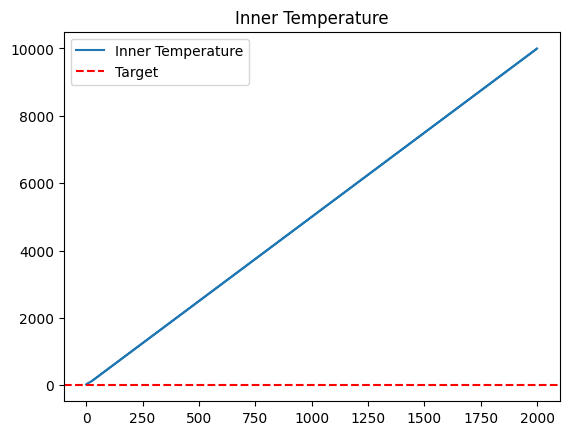

In [118]:
import numpy as np
import matplotlib.pyplot as plt

innert_temp_history = []
action_history = []
reward_history = []
repeat_cnt = 100

def test_model(model_path_name="recurrent_ppo_dryer_control", repeat_cnt=100):
    # 저장된 모델 로드 및 테스트
    env = DryerEnv()
    model = PPO.load(model_path_name)
    model.env = env

    # obs, _ = env.reset()
    obs = env.state

    for i in range(repeat_cnt):
        # 모델 예측 (deterministic=True: 가장 확률 높은 액션 선택)
        in_obs = obs
        in_inner_temp = obs[0]
        action, lstm_states = model.predict(
            obs, 
            deterministic=True
        )
        action = int(action)
        obs, reward, terminated, truncated, _ = model.env.step(action)
        out_obs = obs
        if i % 1 == 0:
            print( f"Step {i}: In ={in_obs}, Action={action}, Reward={reward:.2f}")
            print( f"Step {i}: Out={out_obs}, Action={action}, Reward={reward:.2f}")
        innert_temp_history.append(in_inner_temp)
        innert_temp_history.append(obs[0])
        action_history.append(action)
        reward_history.append(reward)
        
        # if terminated or truncated:
        #     break

test_model(model_path_name=model_path_name, repeat_cnt=1000)

plt.plot(innert_temp_history, label='Inner Temperature')
plt.axhline(15, color='r', linestyle='--', label='Target')
plt.title("Inner Temperature")
plt.legend()
plt.show()